<h1> <font color = Red> <center> GIS Apps in Engineering </h1>
<h3> <font color = Blue> <center> Shaseevarajan Sivanantharajah </h1>

**Work Flow**
1. Get Data
2. Variogram Cloud
3. Emprical semivariogram
4. Theoretical variogram
5. select the 'Best' semi variogram
6. Create a grid
7. Use theortical semi variogram
8. Make plots
9. Embelish

In [15]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import skgstat as skg
from skgstat import Variogram
import numpy as np

In [10]:
path = "/home/harris/Downloads/Shasee/Assignment 9"
os.chdir(path)

In [11]:
cty = gpd.read_file("HardAEA.gpkg")
ECC = gpd.read_file("ECAEA.gpkg")
grid = gpd.read_file("final grid.gpkg")

In [12]:
cty.head()

,CMPTRL_CNT,DPS_CNTY_N,FIPS_ST_CN,TXDOT_CNTY,TXDOT_DIST,CNTY_NM,CNTY_NBR,DIST_NBR,GID,geometry
0,100,100,48199,101,20,Hardin,101,20,69,"MULTIPOLYGON (((184644.803 829662.268, 184649...."


In [13]:
ECC.head()

,StateWellNumber,ParameterCode,EC,LatitudeDD,LongitudeDD,geometry
0,6129803,94.0,353.6,30.511945,-94.447778,POINT (148672.383 827432.266)
1,6131901,94.0,104.0,30.504723,-94.164167,POINT (175849.127 827114.308)
2,6135205,94.0,324.0,30.462501,-94.706389,POINT (123978.977 821569.177)
3,6135501,94.0,384.0,30.437500,-94.673611,POINT (127158.961 818835.617)
4,6135502,94.0,265.5,30.437222,-94.672500,POINT (127265.895 818806.227)


In [14]:
grid.head()

,X,Y,geometry
0,121419.778143,781437.456615,POINT (121419.77814 781437.45662)
1,121737.975409,781437.456615,POINT (121737.97541 781437.45662)
2,122056.172676,781437.456615,POINT (122056.17268 781437.45662)
3,122374.369942,781437.456615,POINT (122374.36994 781437.45662)
4,122692.567208,781437.456615,POINT (122692.56721 781437.45662)


In [19]:
ECcoord = np.array([(geom.x,geom.y) for geom in ECC.geometry])
EC = ECC['EC'].to_numpy()

In [52]:
V1 = skg.Variogram(ECcoord,EC,n_lags=15,maxlag='median',model='spherical', normalize=False,use_nugget=False)

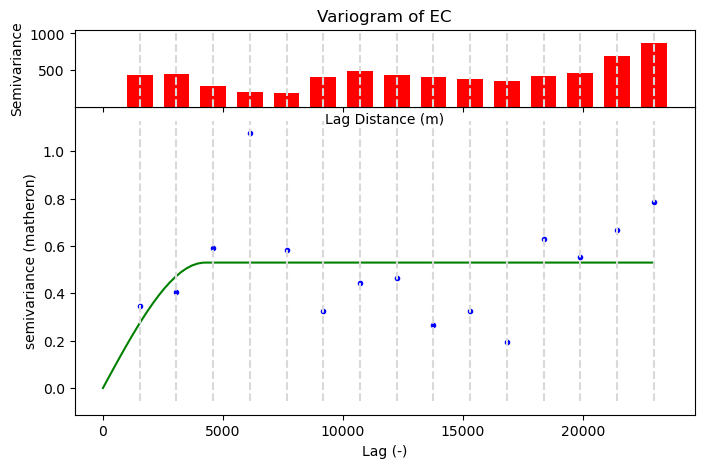

In [53]:
V1.plot()
plt.title("Variogram of EC")
plt.xlabel("Lag Distance (m)")
plt.ylabel("Semivariance")
plt.show()

In [48]:
print(skg.__version__)

1.0.21


In [54]:
V2 = skg.Variogram(ECcoord,EC,n_lags=15,maxlag='median',model='exponential', normalize=False,use_nugget=False)

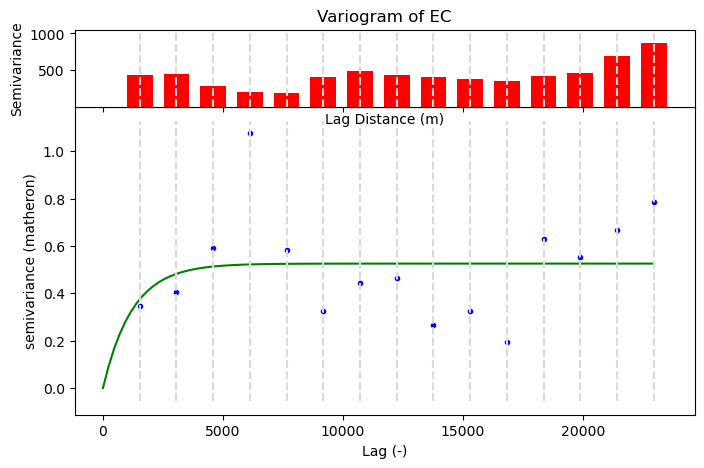

In [55]:
V2.plot()
plt.title("Variogram of EC")
plt.xlabel("Lag Distance (m)")
plt.ylabel("Semivariance")
plt.show()

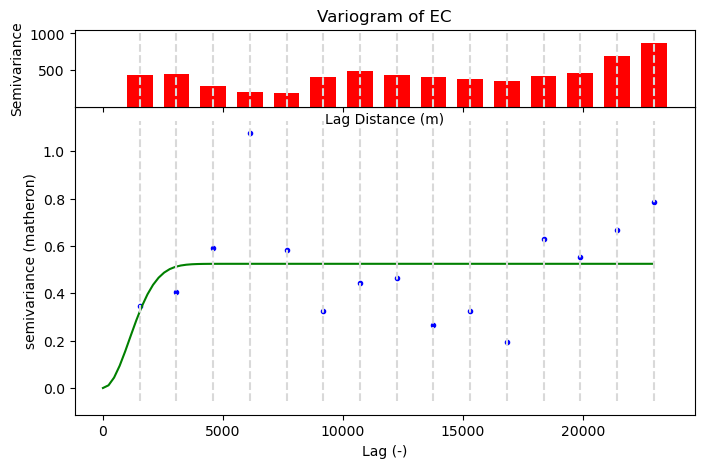

In [56]:
V3 = skg.Variogram(ECcoord,EC,n_lags=15,maxlag='median',model='gaussian', normalize=False,use_nugget=False)
V3.plot()
plt.title("Variogram of EC")
plt.xlabel("Lag Distance (m)")
plt.ylabel("Semivariance")
plt.show()

In [59]:
#Considering Exponentiol as the best one (seems better)
print("Range:", V2.parameters[0])
print("Sill:", V2.parameters[1])

Range: 3678.5340476539222
Sill: 525411.3954767941
